# 🚀 Data Analytics Hackathon

## E-Commerce Customer Satisfaction & Delivery Performance Analysis

### Objective
Analyze marketplace data to understand customer satisfaction and identify the key operational factors associated with low review scores.

### Key Finding
Delivery performance has the strongest observed relationship with customer satisfaction.

Late deliveries are associated with significantly lower review scores compared with early deliveries.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Data Analysis & Visualization

# 📌 Final Insights

### 1. Delivery is the strongest customer-experience signal
Early-delivered orders received substantially higher review scores than late-delivered orders.

### 2. Late delivery creates a major satisfaction gap
Orders delivered 1–7 days late had an average review score of 1.74, while orders delivered more than 14 days early had an average score of 4.31.

### 3. Severe delays do not improve with additional delay
Orders more than 7 days late still had a very low average review score of 1.71.

### 4. Delivery delay and review score show a negative relationship
The correlation between delivery delay and review score was -0.269.

> Correlation indicates association and does not by itself prove causation.

In [1]:
import pandas as pd
import os

# Check uploaded CSV files
csv_files = [f for f in os.listdir('/content') if f.endswith('.csv')]

print("Total CSV files:", len(csv_files))
print("\nFiles:")
for f in csv_files:
    print(f)

Total CSV files: 9

Files:
Document from singhlink4 - products.csv
Document from singhlink4 - sellers.csv
Document from singhlink4 - geolocation.csv
Document from singhlink4 - orders.csv
Document from singhlink4 - customers.csv
Document from singhlink4 - order_items.csv
Document from singhlink4 - order_reviews.csv
Document from singhlink4 - category_translation.csv
Document from singhlink4 - order_payments.csv


In [2]:
import pandas as pd

# Load all datasets
products = pd.read_csv('/content/Document from singhlink4 - products.csv')
sellers = pd.read_csv('/content/Document from singhlink4 - sellers.csv')
geolocation = pd.read_csv('/content/Document from singhlink4 - geolocation.csv')
orders = pd.read_csv('/content/Document from singhlink4 - orders.csv')
customers = pd.read_csv('/content/Document from singhlink4 - customers.csv')
order_items = pd.read_csv('/content/Document from singhlink4 - order_items.csv')
order_reviews = pd.read_csv('/content/Document from singhlink4 - order_reviews.csv')
category_translation = pd.read_csv('/content/Document from singhlink4 - category_translation.csv')
order_payments = pd.read_csv('/content/Document from singhlink4 - order_payments.csv')

print("All datasets loaded successfully! ✅")

# Show shape of each dataset
print("\nDataset Shapes:")
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", order_payments.shape)
print("Reviews:", order_reviews.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Geolocation:", geolocation.shape)
print("Category Translation:", category_translation.shape)

All datasets loaded successfully! ✅

Dataset Shapes:
Orders: (99441, 8)
Order Items: (112650, 6)
Payments: (103886, 5)
Reviews: (100000, 7)
Customers: (99441, 5)
Products: (32951, 9)
Sellers: (3095, 4)
Geolocation: (1000163, 5)
Category Translation: (71, 2)


In [3]:
# STEP 3: Data Quality Check

datasets = {
    "Orders": orders,
    "Order Items": order_items,
    "Payments": order_payments,
    "Reviews": order_reviews,
    "Customers": customers,
    "Products": products,
    "Sellers": sellers,
    "Geolocation": geolocation,
    "Category Translation": category_translation
}

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")

    print("Missing values:")
    print(df.isnull().sum())

    print("\nDuplicate rows:", df.duplicated().sum())


Orders
Missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Duplicate rows: 0

Order Items
Missing values:
order_id         0
order_item_id    0
product_id       0
seller_id        0
price            0
freight_value    0
dtype: int64

Duplicate rows: 0

Payments
Missing values:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Duplicate rows: 0

Reviews
Missing values:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       88285
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Duplica

In [4]:
# Compact Data Quality Summary

summary = []

for name, df in datasets.items():
    summary.append({
        "Dataset": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

quality_summary = pd.DataFrame(summary)

quality_summary

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Orders,99441,8,4908,0
1,Order Items,112650,6,0,0
2,Payments,103886,5,0,0
3,Reviews,100000,7,146532,0
4,Customers,99441,5,0,0
5,Products,32951,9,2448,0
6,Sellers,3095,4,0,0
7,Geolocation,1000163,5,0,261836
8,Category Translation,71,2,0,0


In [5]:
# STEP 4: Find exact missing values

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) > 0:
        print(f"\n{name}")
        print("-" * 40)
        print(missing)


Orders
----------------------------------------
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Reviews
----------------------------------------
review_comment_title      88285
review_comment_message    58247
dtype: int64

Products
----------------------------------------
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [6]:
# STEP 5: Convert date columns to datetime

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Check data types
print(orders[date_columns].dtypes)

# Check date range
print("\nPurchase date range:")
print("Start:", orders['order_purchase_timestamp'].min())
print("End:", orders['order_purchase_timestamp'].max())

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Purchase date range:
Start: 2016-09-04 21:15:19
End: 2018-10-17 17:30:18


In [7]:
# STEP 6: Calculate Delivery Delay

delivered_orders = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].notna()) &
    (orders['order_estimated_delivery_date'].notna())
].copy()

# Delay in days
delivered_orders['delivery_delay_days'] = (
    delivered_orders['order_delivered_customer_date']
    - delivered_orders['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 60 * 60)

# Categorize delivery performance
delivered_orders['delivery_status'] = delivered_orders['delivery_delay_days'].apply(
    lambda x: 'Early' if x < 0 else ('On Time' if x == 0 else 'Late')
)

print("Total delivered orders:", len(delivered_orders))

print("\nDelivery Status:")
print(delivered_orders['delivery_status'].value_counts())

print("\nAverage delivery delay:",
      round(delivered_orders['delivery_delay_days'].mean(), 2), "days")

print("\nDelivery delay statistics:")
print(delivered_orders['delivery_delay_days'].describe())

Total delivered orders: 96470

Delivery Status:
delivery_status
Early    88644
Late      7826
Name: count, dtype: int64

Average delivery delay: -11.18 days

Delivery delay statistics:
count    96470.000000
mean       -11.178126
std         10.184354
min       -146.016123
25%        -16.244065
50%        -11.948102
75%         -6.389815
max        188.975081
Name: delivery_delay_days, dtype: float64


In [8]:
# STEP 7: Delivery Performance vs Customer Satisfaction

# Keep only order_id and review_score
reviews_clean = order_reviews[['order_id', 'review_score']].copy()

# If an order has multiple reviews, take the average score
reviews_clean = reviews_clean.groupby('order_id', as_index=False)['review_score'].mean()

# Merge reviews with delivery information
delivery_reviews = delivered_orders.merge(
    reviews_clean,
    on='order_id',
    how='left'
)

# Compare review scores by delivery status
review_by_delivery = delivery_reviews.groupby('delivery_status').agg(
    orders=('order_id', 'count'),
    average_review=('review_score', 'mean')
).reset_index()

review_by_delivery['average_review'] = review_by_delivery['average_review'].round(2)

print("Review Score by Delivery Status:")
display(review_by_delivery)

# Compare Late vs Early
early_avg = delivery_reviews[
    delivery_reviews['delivery_status'] == 'Early'
]['review_score'].mean()

late_avg = delivery_reviews[
    delivery_reviews['delivery_status'] == 'Late'
]['review_score'].mean()

print("\nEarly delivery average review:", round(early_avg, 2))
print("Late delivery average review:", round(late_avg, 2))

print("\nDifference in review score:",
      round(early_avg - late_avg, 2))

Review Score by Delivery Status:


,delivery_status,orders,average_review
0,Early,88644,4.28
1,Late,7826,2.55



Early delivery average review: 4.28
Late delivery average review: 2.55

Difference in review score: 1.74


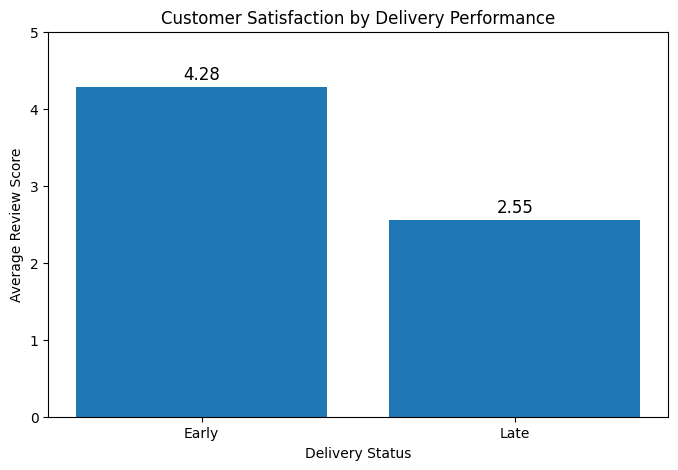

In [9]:
import matplotlib.pyplot as plt

# Bar chart: Delivery Status vs Average Review Score

plt.figure(figsize=(8, 5))

plt.bar(
    review_by_delivery['delivery_status'],
    review_by_delivery['average_review']
)

plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.title("Customer Satisfaction by Delivery Performance")
plt.ylim(0, 5)

# Show values on bars
for i, value in enumerate(review_by_delivery['average_review']):
    plt.text(i, value + 0.1, str(value), ha='center', fontsize=12)

plt.show()

In [10]:
# STEP 9: Category-wise Delivery Performance

# Add product category to order items
items_category = order_items[['order_id', 'product_id']].merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# One category per order:
# For multi-item orders, use the first available category
order_category = items_category.groupby('order_id')['product_category_name'].first().reset_index()

# Add category to delivery + review data
category_delivery = delivery_reviews.merge(
    order_category,
    on='order_id',
    how='left'
)

# Fill missing category
category_delivery['product_category_name'] = (
    category_delivery['product_category_name']
    .fillna('Unknown')
)

# Category-wise comparison
category_analysis = category_delivery.groupby('product_category_name').agg(
    orders=('order_id', 'count'),
    avg_review=('review_score', 'mean'),
    late_orders=('delivery_status', lambda x: (x == 'Late').sum())
).reset_index()

# Late delivery percentage
category_analysis['late_percentage'] = (
    category_analysis['late_orders'] /
    category_analysis['orders'] * 100
)

# Round values
category_analysis['avg_review'] = category_analysis['avg_review'].round(2)
category_analysis['late_percentage'] = category_analysis['late_percentage'].round(2)

# Focus on categories with at least 100 orders
category_analysis_filtered = category_analysis[
    category_analysis['orders'] >= 100
].copy()

# Sort by lowest review score
category_analysis_filtered = category_analysis_filtered.sort_values(
    'avg_review'
)

print("Lowest-rated categories with at least 100 orders:")
display(category_analysis_filtered.head(10))

print("\nHighest-rated categories with at least 100 orders:")
display(category_analysis_filtered.tail(10))

Lowest-rated categories with at least 100 orders:


,product_category_name,orders,avg_review,late_orders,late_percentage
56,moveis_escritorio,1245,3.64,115,9.24
39,fashion_roupa_masculina,106,3.79,5,4.72
8,audio,346,3.83,45,13.01
72,telefonia_fixa,211,3.94,11,5.21
15,casa_conforto,368,3.95,39,10.60
40,fashion_underwear_e_moda_praia,117,3.98,15,12.82
14,cama_mesa_banho,9158,3.99,808,8.82
26,construcao_ferramentas_seguranca,155,4.01,7,4.52
17,casa_construcao,471,4.03,39,8.28
0,Unknown,1332,4.04,119,8.93



Highest-rated categories with at least 100 orders:


,product_category_name,orders,avg_review,late_orders,late_percentage
35,fashion_calcados,233,4.25,15,6.44
63,perfumaria,3075,4.26,228,7.41
64,pet_shop,1683,4.27,106,6.30
60,papelaria,2253,4.29,176,7.81
25,construcao_ferramentas_jardim,184,4.29,13,7.07
2,alimentos,436,4.31,44,10.09
51,malas_acessorios,1013,4.37,56,5.53
50,livros_tecnicos,255,4.43,28,10.98
3,alimentos_bebidas,219,4.44,14,6.39
49,livros_interesse_geral,492,4.53,34,6.91


In [11]:
# STEP 10: State-wise Delivery Performance

# Add customer state
state_data = delivery_reviews.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

# State-wise analysis
state_analysis = state_data.groupby('customer_state').agg(
    orders=('order_id', 'count'),
    avg_review=('review_score', 'mean'),
    late_orders=('delivery_status', lambda x: (x == 'Late').sum())
).reset_index()

# Late delivery percentage
state_analysis['late_percentage'] = (
    state_analysis['late_orders'] /
    state_analysis['orders'] * 100
)

# Round
state_analysis['avg_review'] = state_analysis['avg_review'].round(2)
state_analysis['late_percentage'] = state_analysis['late_percentage'].round(2)

# Only states with at least 100 orders
state_analysis = state_analysis[
    state_analysis['orders'] >= 100
].sort_values('late_percentage', ascending=False)

print("States with highest late-delivery percentage:")
display(state_analysis.head(10))

print("\nStates with lowest average review:")
display(
    state_analysis.sort_values('avg_review').head(10)
)

States with highest late-delivery percentage:


,customer_state,orders,avg_review,late_orders,late_percentage
1,AL,397,3.83,95,23.93
9,MA,717,3.81,141,19.67
16,PI,476,3.98,76,15.97
5,CE,1279,3.94,196,15.32
24,SE,335,3.90,51,15.22
4,BA,3256,3.91,457,14.04
18,RJ,12350,3.95,1664,13.47
26,TO,274,4.16,35,12.77
13,PA,946,3.89,117,12.37
7,ES,1995,4.05,244,12.23



States with lowest average review:


,customer_state,orders,avg_review,late_orders,late_percentage
9,MA,717,3.81,141,19.67
1,AL,397,3.83,95,23.93
13,PA,946,3.89,117,12.37
24,SE,335,3.90,51,15.22
4,BA,3256,3.91,457,14.04
5,CE,1279,3.94,196,15.32
18,RJ,12350,3.95,1664,13.47
16,PI,476,3.98,76,15.97
7,ES,1995,4.05,244,12.23
14,PB,517,4.06,57,11.03


In [12]:
# STEP 11: Monthly Marketplace Performance

# Create month column
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Monthly orders
monthly_orders = orders.groupby('month').agg(
    total_orders=('order_id', 'nunique')
).reset_index()

# Monthly revenue from order items
order_revenue = order_items.groupby('order_id')['price'].sum().reset_index()

# Merge revenue with orders
orders_revenue = orders[['order_id', 'month']].merge(
    order_revenue,
    on='order_id',
    how='left'
)

monthly_revenue = orders_revenue.groupby('month').agg(
    revenue=('price', 'sum')
).reset_index()

# Monthly review score
monthly_reviews = orders[['order_id', 'month']].merge(
    reviews_clean,
    on='order_id',
    how='left'
)

monthly_review_score = monthly_reviews.groupby('month').agg(
    avg_review=('review_score', 'mean')
).reset_index()

# Combine everything
monthly_performance = monthly_orders.merge(
    monthly_revenue,
    on='month',
    how='left'
).merge(
    monthly_review_score,
    on='month',
    how='left'
)

monthly_performance['revenue'] = monthly_performance['revenue'].round(2)
monthly_performance['avg_review'] = monthly_performance['avg_review'].round(2)

display(monthly_performance)

,month,total_orders,revenue,avg_review
0,2016-09,4,267.36,1.00
1,2016-10,324,49507.66,3.52
2,2016-12,1,10.90,5.00
3,2017-01,800,120312.87,4.05
4,2017-02,1780,247303.02,4.00
5,2017-03,2682,374344.30,4.06
6,2017-04,2404,359927.23,4.03
7,2017-05,3700,506071.14,4.12
8,2017-06,3245,433038.60,4.13
9,2017-07,4026,498031.48,4.16


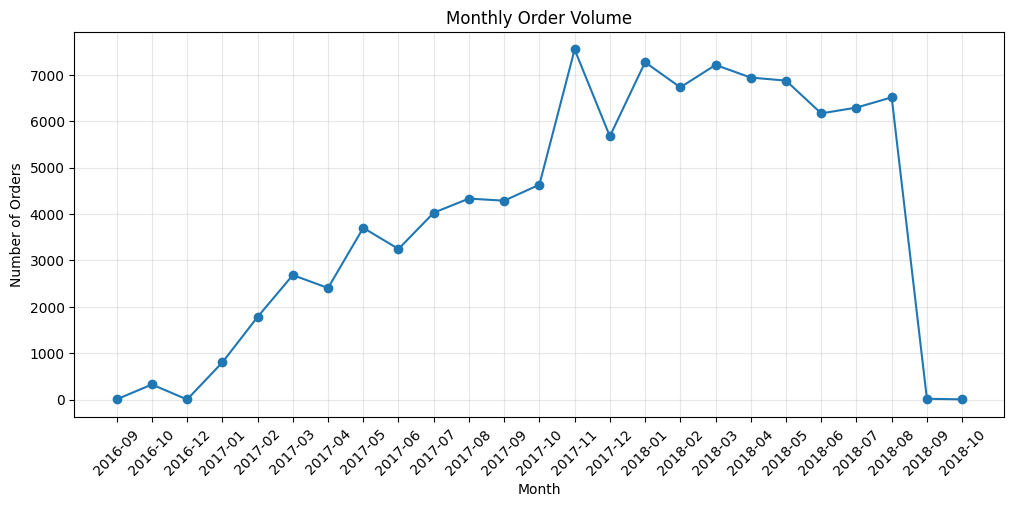

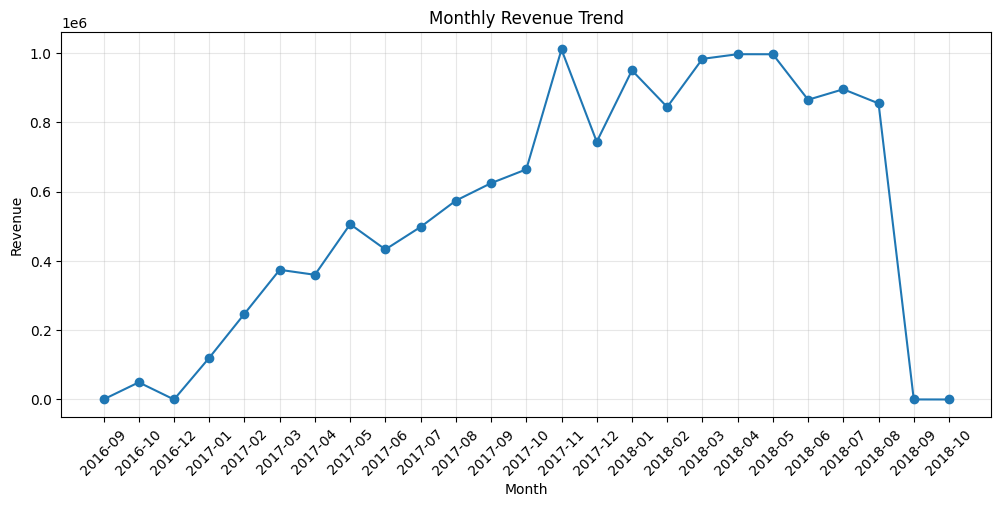

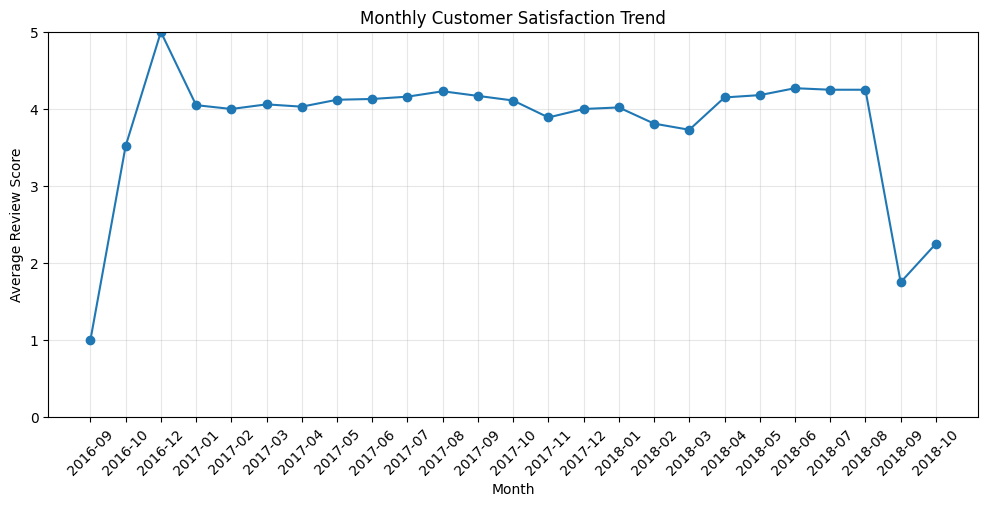

In [13]:
# STEP 12: Marketplace Performance Visualizations

import matplotlib.pyplot as plt

# Convert month to string for plotting
plot_data = monthly_performance.copy()
plot_data['month'] = plot_data['month'].astype(str)

# 1. Monthly Orders
plt.figure(figsize=(12, 5))
plt.plot(plot_data['month'], plot_data['total_orders'], marker='o')
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.title("Monthly Order Volume")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()


# 2. Monthly Revenue
plt.figure(figsize=(12, 5))
plt.plot(plot_data['month'], plot_data['revenue'], marker='o')
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()


# 3. Monthly Average Review Score
plt.figure(figsize=(12, 5))
plt.plot(plot_data['month'], plot_data['avg_review'], marker='o')
plt.xlabel("Month")
plt.ylabel("Average Review Score")
plt.title("Monthly Customer Satisfaction Trend")
plt.ylim(0, 5)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

In [14]:
# STEP 13: Product Category Performance

# Add category to order items
category_items = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# Add English category names
category_items = category_items.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

# Use English name where available
category_items['category'] = (
    category_items['product_category_name_english']
    .fillna(category_items['product_category_name'])
    .fillna('Unknown')
)

# Category performance
category_performance = category_items.groupby('category').agg(
    orders=('order_id', 'nunique'),
    revenue=('price', 'sum'),
    avg_price=('price', 'mean')
).reset_index()

# Add review score by category
category_reviews = category_delivery.groupby('product_category_name').agg(
    avg_review=('review_score', 'mean')
).reset_index()

category_reviews['category'] = (
    category_reviews['product_category_name']
)

category_performance = category_performance.merge(
    category_reviews[['category', 'avg_review']],
    on='category',
    how='left'
)

# Round values
category_performance['revenue'] = category_performance['revenue'].round(2)
category_performance['avg_price'] = category_performance['avg_price'].round(2)
category_performance['avg_review'] = category_performance['avg_review'].round(2)

# Minimum 100 orders for meaningful comparison
category_performance_filtered = category_performance[
    category_performance['orders'] >= 100
].copy()

print("TOP 10 CATEGORIES BY ORDERS")
display(
    category_performance_filtered
    .sort_values('orders', ascending=False)
    .head(10)
)

print("\nTOP 10 CATEGORIES BY REVENUE")
display(
    category_performance_filtered
    .sort_values('revenue', ascending=False)
    .head(10)
)

print("\nLOWEST REVIEW CATEGORIES")
display(
    category_performance_filtered
    .sort_values('avg_review')
    .head(10)
)

TOP 10 CATEGORIES BY ORDERS


,category,orders,revenue,avg_price,avg_review
8,bed_bath_table,9417,1036988.68,93.30,NaN
44,health_beauty,8836,1258681.34,130.16,NaN
68,sports_leisure,7720,988048.97,114.34,NaN
16,computers_accessories,6689,911954.32,116.51,NaN
40,furniture_decor,6449,729762.49,87.56,NaN
50,housewares,5884,632248.66,90.79,NaN
73,watches_gifts,5624,1205005.68,201.14,NaN
71,telephony,4199,323667.53,71.21,NaN
6,auto,3897,592720.11,139.96,NaN
72,toys,3886,483946.60,117.55,NaN



TOP 10 CATEGORIES BY REVENUE


,category,orders,revenue,avg_price,avg_review
44,health_beauty,8836,1258681.34,130.16,NaN
73,watches_gifts,5624,1205005.68,201.14,NaN
8,bed_bath_table,9417,1036988.68,93.30,NaN
68,sports_leisure,7720,988048.97,114.34,NaN
16,computers_accessories,6689,911954.32,116.51,NaN
40,furniture_decor,6449,729762.49,87.56,NaN
21,cool_stuff,3632,635290.85,167.36,4.22
50,housewares,5884,632248.66,90.79,NaN
6,auto,3897,592720.11,139.96,NaN
43,garden_tools,3518,485256.46,111.63,NaN



LOWEST REVIEW CATEGORIES


,category,orders,revenue,avg_price,avg_review
5,audio,350,50688.50,139.25,3.83
0,Unknown,1451,179535.28,112.00,4.04
55,market_place,280,28378.47,91.25,4.09
17,consoles_games,1062,157465.22,138.49,4.16
21,cool_stuff,3632,635290.85,167.36,4.22
62,pet_shop,1710,214315.41,110.07,4.27
1,agro_industry_and_commerce,182,72530.47,342.12,NaN
2,air_conditioning,253,55024.96,185.27,NaN
3,art,202,24202.64,115.80,NaN
6,auto,3897,592720.11,139.96,NaN


In [15]:
# STEP 14: Payment Behavior

payment_analysis = order_payments.groupby('payment_type').agg(
    orders=('order_id', 'nunique'),
    total_payment=('payment_value', 'sum'),
    avg_payment=('payment_value', 'mean'),
    avg_installments=('payment_installments', 'mean')
).reset_index()

payment_analysis['total_payment'] = payment_analysis['total_payment'].round(2)
payment_analysis['avg_payment'] = payment_analysis['avg_payment'].round(2)
payment_analysis['avg_installments'] = payment_analysis['avg_installments'].round(2)

display(payment_analysis.sort_values('orders', ascending=False))

,payment_type,orders,total_payment,avg_payment,avg_installments
1,credit_card,76505,12542084.19,163.32,3.51
0,boleto,19784,2869361.27,145.03,1.00
4,voucher,3866,379436.87,65.70,1.00
2,debit_card,1528,217989.79,142.57,1.00
3,not_defined,3,0.00,0.00,1.00


In [16]:
# STEP 15: Root Cause Analysis
# Relationship between delivery delay and review score

correlation = delivery_reviews[
    ['delivery_delay_days', 'review_score']
].dropna().corr()

print("Correlation between Delivery Delay and Review Score:")
print(round(correlation.loc['delivery_delay_days', 'review_score'], 3))

Correlation between Delivery Delay and Review Score:
-0.269


In [17]:
# STEP 15B: Review Score by Delivery Delay

delay_analysis = delivery_reviews.copy()

# Create delivery delay groups
delay_analysis['delay_group'] = pd.cut(
    delay_analysis['delivery_delay_days'],
    bins=[-999, -14, -7, 0, 7, 14, 999],
    labels=[
        'More than 14 days early',
        '8-14 days early',
        '1-7 days early',
        'On time / 0-1 day',
        '1-7 days late',
        'More than 7 days late'
    ]
)

delay_summary = delay_analysis.groupby(
    'delay_group',
    observed=True
).agg(
    orders=('order_id', 'nunique'),
    avg_review=('review_score', 'mean')
).reset_index()

delay_summary['avg_review'] = delay_summary['avg_review'].round(2)

print("Review Score by Delivery Performance:")
display(delay_summary)

Review Score by Delivery Performance:


,delay_group,orders,avg_review
0,More than 14 days early,34939,4.31
1,8-14 days early,36364,4.30
2,1-7 days early,17341,4.19
3,On time / 0-1 day,4481,3.16
4,1-7 days late,1790,1.74
5,More than 7 days late,1555,1.71


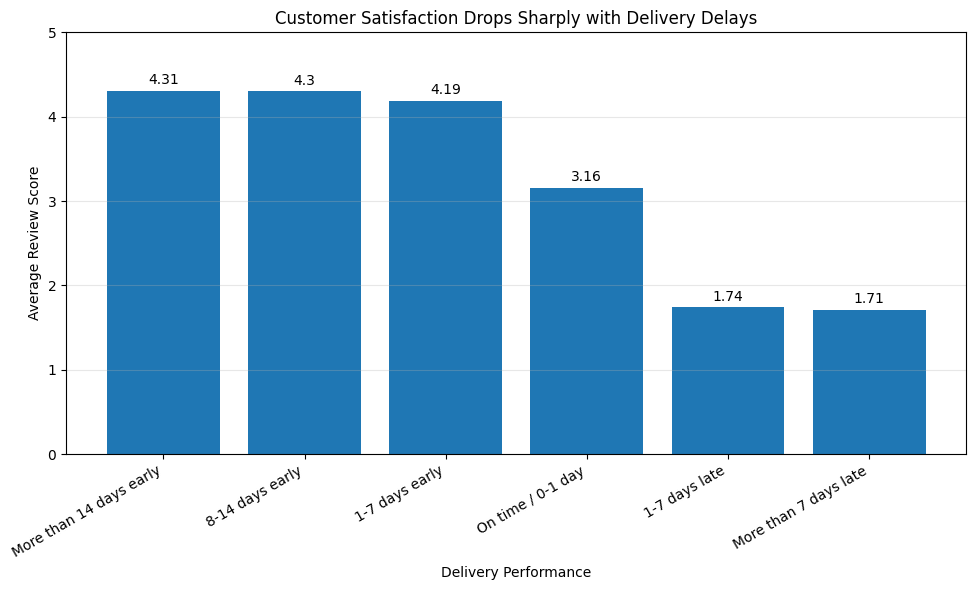

In [18]:
# STEP 16: Final Delivery vs Review Chart

plt.figure(figsize=(10, 6))

plt.bar(
    delay_summary['delay_group'].astype(str),
    delay_summary['avg_review']
)

plt.xlabel("Delivery Performance")
plt.ylabel("Average Review Score")
plt.title("Customer Satisfaction Drops Sharply with Delivery Delays")
plt.ylim(0, 5)

plt.xticks(rotation=30, ha='right')

# Add values on bars
for i, value in enumerate(delay_summary['avg_review']):
    plt.text(i, value + 0.08, str(value), ha='center')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# STEP 17: Final Key Insights

final_insights = pd.DataFrame({
    'Finding': [
        'Early delivery vs Late delivery',
        'Delivery delay correlation',
        'On-time delivery satisfaction',
        '1-7 days late satisfaction',
        'More than 7 days late satisfaction'
    ],
    'Result': [
        '4.28 vs 2.55 average review',
        '-0.269 correlation',
        '3.16 average review',
        '1.74 average review',
        '1.71 average review'
    ],
    'Business Meaning': [
        'Late delivery is strongly associated with lower customer satisfaction',
        'Review scores tend to decrease as delivery delay increases',
        'Even small delivery delays reduce satisfaction',
        'Late delivery creates a major customer experience problem',
        'Severe delays keep satisfaction extremely low'
    ]
})

display(final_insights)

,Finding,Result,Business Meaning
0,Early delivery vs Late delivery,4.28 vs 2.55 average review,Late delivery is strongly associated with lowe...
1,Delivery delay correlation,-0.269 correlation,Review scores tend to decrease as delivery del...
2,On-time delivery satisfaction,3.16 average review,Even small delivery delays reduce satisfaction
3,1-7 days late satisfaction,1.74 average review,Late delivery creates a major customer experie...
4,More than 7 days late satisfaction,1.71 average review,Severe delays keep satisfaction extremely low


In [20]:
# STEP 18: Actionable Recommendations

recommendations = pd.DataFrame({
    'Priority': ['1', '2', '3', '4'],
    'Recommendation': [
        'Improve delivery reliability',
        'Focus on high-risk states',
        'Monitor delivery performance by category',
        'Send proactive delay notifications'
    ],
    'Why': [
        'Late orders have much lower review scores',
        'Some states show lower reviews and higher late-order rates',
        'High-volume categories can have greater business impact',
        'Early communication can reduce customer frustration'
    ],
    'Expected Impact': [
        'Higher customer satisfaction',
        'Lower regional delivery issues',
        'Better operational prioritization',
        'Better customer experience'
    ]
})

display(recommendations)

,Priority,Recommendation,Why,Expected Impact
0,1,Improve delivery reliability,Late orders have much lower review scores,Higher customer satisfaction
1,2,Focus on high-risk states,Some states show lower reviews and higher late...,Lower regional delivery issues
2,3,Monitor delivery performance by category,High-volume categories can have greater busine...,Better operational prioritization
3,4,Send proactive delay notifications,Early communication can reduce customer frustr...,Better customer experience
